# SBI with Bayesfow: an introduction to diffusion model

This repository is taken from the accompany material of https://arxiv.org/abs/2512.20685, you can find all the experiments at https://github.com/bayesflow-org/diffusion-experiments

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import os

drive_path = '/content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/'

if os.path.exists(drive_path):
    print(f"Contents of {drive_path}:")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"The directory {drive_path} does not exist. Please check the path.")

Contents of /content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/:
example_simulations.png
kinematics_helper.py
adaptive_inference.jpg
score_visual.jpg
diffusion_model_review.jpeg
fm_cm_visual.jpg
c2st_benchmark_boxplot_best.jpeg
__pycache__


# Diffusion Models In Simulation-Based Inference: A Tutorial

This notebook introduces answers the following questions:

1. **What is simulation-based inference (SBI)?**
2. **What are diffusion models?**
3. **Why are diffusion models so special for SBI?**

_Author: Jonas Arruda_

In [3]:
!pip install bayesflow keras

In [4]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import logging
from IPython.display import Image


import numpy as np
import matplotlib.pyplot as plt
import keras

import ipywidgets as widgets
logging.getLogger("matplotlib").setLevel(logging.ERROR)


from collections import OrderedDict
from matplotlib import cm, patches
import matplotlib.pyplot as plt
import numpy as np

import scipy
from sklearn.cluster import MeanShift
from sklearn.neighbors import KernelDensity


In [5]:
# @title Plotting Function and Simulator
#

class InverseKinematicsModel:
    n_parameters = 4
    n_observations = 2
    name = "inverse-kinematics"

    def __init__(self, lens=[0.5, 0.5, 1.0], sigmas=[0.25, 0.5, 0.5, 0.5], linecolors=["gray"] * 3):
        self.name = "inverse-kinematics"
        self.lens = np.array(lens)
        self.sigmas = np.array(sigmas)
        self.rangex = (-0.35, 2.25)
        self.rangey = (-1.3, 1.3)

        cmap = cm.tab20c
        self.colors = [[cmap(4 * c_index), cmap(4 * c_index + 1), cmap(4 * c_index + 2)] for c_index in range(5)][-1]
        self.linecolors = linecolors

        self.prior_reference = OrderedDict(
            theta_1=scipy.stats.norm(0, sigmas[0]),
            theta_2=scipy.stats.norm(0, sigmas[1]),
            theta_3=scipy.stats.norm(0, sigmas[2]),
            theta_4=scipy.stats.norm(0, sigmas[3]),
        )

    def sample_prior(self, N):
        return np.random.randn(N, 4) * self.sigmas

    @staticmethod
    def segment_points(p_, length, angle):
        p = np.array(p_)
        angle = np.array(angle)
        p[:, 0] += length * np.cos(angle)
        p[:, 1] += length * np.sin(angle)
        return p_, p

    def forward_process(self, x):
        start = np.stack([np.zeros((x.shape[0])), x[:, 0]], axis=1)
        _, x1 = self.segment_points(start, self.lens[0], x[:, 1])
        _, x2 = self.segment_points(x1, self.lens[1], x[:, 1] + x[:, 2])
        _, y = self.segment_points(x2, self.lens[2], x[:, 1] + x[:, 2] + x[:, 3])
        return y

    @staticmethod
    def find_MAP(x):
        mean_shift = MeanShift()
        mean_shift.fit(x)
        centers = mean_shift.cluster_centers_
        kde = KernelDensity(kernel="gaussian", bandwidth=0.1).fit(x)

        best_center = (None, -np.inf)
        dens = kde.score_samples(centers)
        for c, d in zip(centers, dens):
            if d > best_center[1]:
                best_center = (c.copy(), d)

        dist_to_best = np.sum((x - best_center[0]) ** 2, axis=1)
        return np.argmin(dist_to_best)

    @staticmethod
    def arcarrow(
        start,
        target,
        dist=0.3,
        open_angle=150,
        kw=dict(arrowstyle="<->, head_width=1, head_length=2", ec="black", lw=0.5),
    ):
        direction = target - start
        angle = np.arctan2(direction[1], direction[0])

        angle1 = angle - np.radians(open_angle / 2)
        x1 = start[0] + dist * np.cos(angle1)
        y1 = start[1] + dist * np.sin(angle1)
        angle2 = angle + np.radians(open_angle / 2)
        x2 = start[0] + dist * np.cos(angle2)
        y2 = start[1] + dist * np.sin(angle2)

        plt.gca().add_patch(patches.FancyArrowPatch((x1, y1), (x2, y2), connectionstyle="arc3, rad=.6", **kw))

    def draw_isolines(self, samples, color, filter_width, ax=None):
        if not filter_width > 0:
            return

        x = np.array(samples)

        starting_pos = np.zeros((x.shape[0], 2))
        starting_pos[:, 1] = x[:, 0]

        x0, x1 = self.segment_points(starting_pos, self.lens[0], x[:, 1])
        x1, x2 = self.segment_points(x1, self.lens[1], x[:, 1] + x[:, 2])
        x2, y = self.segment_points(x2, self.lens[2], x[:, 1] + x[:, 2] + x[:, 3])

        hist, xbins, ybins = np.histogram2d(y[:, 0], y[:, 1], bins=600, range=[self.rangex, self.rangey], density=True)
        hist = scipy.ndimage.gaussian_filter(hist, filter_width)

        percentile = 0.03 * np.sum(hist)
        for q in np.logspace(-99, np.log10(np.max(hist)), 8000, endpoint=True):
            if np.sum(hist[hist < q]) > percentile:
                break
        else:
            q = 1.0

        X, Y = np.meshgrid(0.5 * (xbins[:-1] + xbins[1:]), 0.5 * (ybins[:-1] + ybins[1:]))

        if ax is None:
            plt.contour(X, Y, hist.T, [q], colors=color, linewidths=0.7, zorder=3)
        else:
            ax.contour(X, Y, hist.T, [q], colors=color, linewidths=0.7, zorder=3)

    @staticmethod
    def init_plot():
        return plt.figure(figsize=(8, 8))

    def update_plot_ax(
        self,
        ax,
        x,
        y_target,
        exemplar=None,
        arrows=False,
        target_label=False,
        vline_color="black",
        exemplar_color="#e6e7eb",
        cross_color="maroon",
    ):
        x = np.array(x)  # [:4000, :]
        if exemplar is None:
            exemplar = self.find_MAP(x)

        starting_pos = np.zeros((x.shape[0], 2))
        starting_pos[:, 1] = x[:, 0]
        x0, x1 = self.segment_points(starting_pos, self.lens[0], x[:, 1])
        x1, x2 = self.segment_points(x1, self.lens[1], x[:, 1] + x[:, 2])
        x2, x3 = self.segment_points(x2, self.lens[2], x[:, 1] + x[:, 2] + x[:, 3])

        ax.axvline(x=0, c=vline_color, linewidth=1, alpha=0.8)

        if not arrows:
            l_cross = 0.6
            ax.plot(
                [y_target[0] - l_cross, y_target[0] + l_cross],
                [y_target[1], y_target[1]],
                ls="-",
                c=cross_color,
                linewidth=0.8,
                alpha=1.0,
                rasterized=True,
            )  # , zorder=-1)
            ax.plot(
                [y_target[0], y_target[0]],
                [y_target[1] - l_cross, y_target[1] + l_cross],
                ls="-",
                c=cross_color,
                linewidth=0.8,
                alpha=1.0,
                rasterized=True,
            )  # , zorder=-1)
            if target_label:
                ax.text(
                    y_target[0] + 0.15,
                    y_target[1] + 0.15,
                    target_label,
                    ha="left",
                    va="bottom",
                    color="magenta",
                    fontsize=10,
                )

        opts = {
            "alpha": 0.10,
            "scale": 1,
            "angles": "xy",
            "scale_units": "xy",
            "headlength": 0,
            "headaxislength": 0,
            "linewidth": 1.0,
            "rasterized": True,
        }
        ax.quiver(x0[:, 0], x0[:, 1], (x1 - x0)[:, 0], (x1 - x0)[:, 1], **{"color": self.linecolors[0], **opts})
        ax.quiver(x1[:, 0], x1[:, 1], (x2 - x1)[:, 0], (x2 - x1)[:, 1], **{"color": self.linecolors[1], **opts})
        ax.quiver(x2[:, 0], x2[:, 1], (x3 - x2)[:, 0], (x3 - x2)[:, 1], **{"color": self.linecolors[2], **opts})
        ax.scatter(x3[:, 0], x3[:, 1], color=self.linecolors[0], s=1, rasterized=True, alpha=0.20)

        ax.plot(
            [x0[exemplar, 0], x1[exemplar, 0], x2[exemplar, 0]],
            [x0[exemplar, 1], x1[exemplar, 1], x2[exemplar, 1]],
            "-",
            color=exemplar_color,
            linewidth=2,
            zorder=4,
            rasterized=True,
        )

        if arrows:
            ax.annotate(
                s="",
                xy=(-0.125, -0.5),
                xytext=(-0.125, 0.5),
                arrowprops=dict(arrowstyle="<->, head_width=.1, head_length=.2", ec="black", lw="0.5"),
                zorder=2,
            )
            self.arcarrow(x0[exemplar, :], x1[exemplar, :])
            self.arcarrow(x1[exemplar, :], x2[exemplar, :])
            self.arcarrow(x2[exemplar, :], x3[exemplar, :])
            ax.text(-0.09, -0.60, r"$x_1$", ha="center", va="center", fontsize=10)
            ax.text(0.13, -0.38, r"$x_2$", ha="center", va="center", fontsize=10)
            ax.text(0.60, -0.40, r"$x_3$", ha="center", va="center", fontsize=10)
            ax.text(1.10, -0.44, r"$x_4$", ha="center", va="center", fontsize=10)
            ax.text(1.97, -0.27, r"$\mathbf{y}$", ha="center", va="center", fontsize=10)

        ax.arrow(
            x2[exemplar, 0],
            x2[exemplar, 1],
            x3[exemplar, 0] - x2[exemplar, 0],
            x3[exemplar, 1] - x2[exemplar, 1],
            color=exemplar_color,
            linewidth=2,
            head_width=0.05,
            head_length=0.04,
            overhang=0.1,
            length_includes_head=True,
            zorder=4,
        )
        ax.scatter(
            [
                x0[exemplar, 0],
            ],
            [
                x0[exemplar, 1],
            ],
            s=40,
            marker="s",
            linewidth=1,
            edgecolors="black",
            facecolors=exemplar_color,
            alpha=0.8,
            zorder=3,
            rasterized=True,
        )
        ax.scatter(
            [x0[exemplar, 0], x1[exemplar, 0], x2[exemplar, 0]],
            [x0[exemplar, 1], x1[exemplar, 1], x2[exemplar, 1]],
            s=20,
            linewidth=1,
            edgecolors="black",
            facecolors=exemplar_color,
            alpha=0.8,
            zorder=5,
            rasterized=True,
        )

        ax.set_xlim(-0.01, 1.8)
        ax.set_ylim(*self.rangey)
        ax.set_aspect("equal")

        ax.set_xticks([])
        ax.set_yticks([])

        return ax

## Let's start with an example inference problem: [Inverse Kinematics](https://arxiv.org/pdf/2101.10763.pdf)


We consider a simple 3-segment planar robot arm with unknown configuration:
- one scalar **height offset** $h$,
- three **joint angles** $\alpha_1$, $\alpha_2$, $\alpha_3$.


The goal is: given an end position $\color{red}{\mathbf{x}}$ of a robot arm, infer the unknown arm configuration $\boldsymbol{\theta}=(h, \alpha_1, \alpha_2, \alpha_3)$.
Hence, we want to learn a mapping $\mathbf{x} \mapsto \boldsymbol\theta= (h, \alpha_1, \alpha_2, \alpha_3)$.

**Important:** this is a deliberately *non-identifiable* setting:
different angle combinations can yield very similar end positions.
That makes the inference task naturally **multimodal** and therefore a good stress test
for flexible inference methods such as diffusion models.

The image file exists at: /content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/example_simulations.png


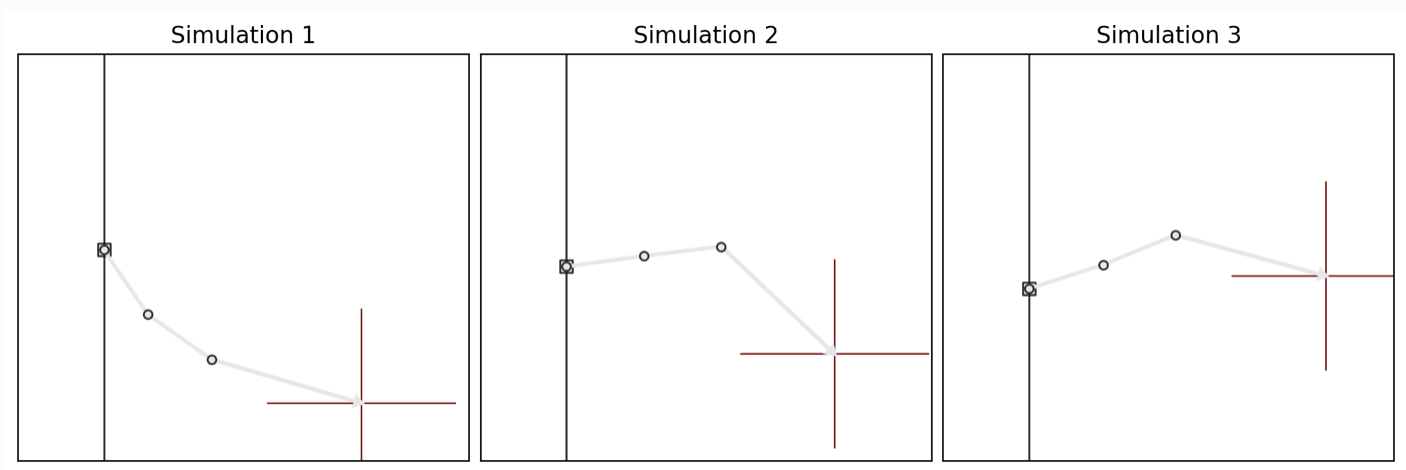

In [6]:
image_path = os.path.join(drive_path, 'example_simulations.png')

if os.path.exists(image_path):
    print(f"The image file exists at: {image_path}")
    display(Image(filename=image_path))
else:
    print(f"Error: The image file does not exist at: {image_path}")


## How to solve this problem?

We will train a neural network to approximate the posterior distribution for the simple **inverse kinematics** problem.

Concretely, we will see how to:
- define a *prior* over parameters and a *simulator* producing synthetic observations,
- generate a training dataset by forward simulation,
- train an amortized inference model using **diffusion-based SBI** in [BayesFlow](https://bayesflow.org),
- draw approximate posterior samples for a new observation,
- compare diffusion models to *flow matching* and *consistency models*,
- make *post-hoc modifications* to inference via guided sampling.

## 1. Simulation-Based Inference (SBI)

In Bayesian inference, we want to infer the **posterior distribution**
$p(\boldsymbol\theta \mid \mathbf{x})$: a probability distribution over parameters
$\boldsymbol\theta$ given observed data $\mathbf{x}$.

A standard Bayesian workflow needs a prior $p(\boldsymbol\theta)$ and the likelihood $p(\mathbf{x}\mid \boldsymbol\theta)$ to be able to compute the posterior:

$p(\boldsymbol\theta\mid \mathbf{x}) \propto p(\mathbf{x}\mid\boldsymbol\theta)\,p(\boldsymbol\theta)$.


#### Key idea in **simulation-based inference (SBI)**:

Often we can **simulate** realistic data from the model without being able to evaluate the likelihood density and "fit" the model.


### SBI in one sentence

If we can sample from $p(\mathbf{x}\mid \boldsymbol\theta) p(\boldsymbol\theta)$, we can train a neural network
to approximate $p(\boldsymbol\theta \mid \mathbf{x})$ directly.


### Training a neural posterior estimator

1. We generate many simulated training pairs:
$(\boldsymbol\theta_i, \mathbf{x}_i) \sim p(\boldsymbol\theta)p(\mathbf{x}\mid\boldsymbol\theta)$
2. We train a neural network to learn the mapping
$\mathbf{x} \mapsto p(\boldsymbol\theta\mid \mathbf{x})$ (or something related to that mapping).

After training, inference for a new observation $\mathbf{x}_{\mathrm{obs}}$
becomes a fast forward-pass procedure:
$\boldsymbol\theta^{(1)},\dots,\boldsymbol\theta^{(N)} \sim q_\phi(\boldsymbol\theta\mid \mathbf{x}_{\mathrm{obs}})$,
where $q_\phi$ is the learned posterior approximation.

## SBI in [BayesFlow](https://bayesflow.org)

BayesFlow is a flexible Python library for efficient simulation-based inference (SBI) with neural networks, including diffusion models.

So let's train a neural posterior estimator! In BayesFlow, SBI workflows can be executed in just a few lines of code, as illustrated by the conceptual snippet below:


```python
import bayesflow as bf

# 1. Define prior and simulator
def my_prior():
    return {'parameters': θ}

def my_observation_model(parameters):
    return {'sim_data': x}

simulator = bf.make_simulator([my_prior, my_observation_model])

# 2. Create workflow
workflow = bf.BasicWorkflow(
    simulator=simulator,
    inference_network=bf.networks.DiffusionModel(...)
)

# 3. Train
workflow.fit_online(epochs=100)

# 4. Infer (amortized)
posterior_samples = workflow.sample(conditions=new_data)

# 5. Diagnose
...
```

## Solving [inverse kinematics](https://arxiv.org/pdf/2101.10763.pdf) with BayesFlow

In [7]:
import bayesflow as bf

INFO:bayesflow:Using backend 'jax'


In [8]:
def prior():
    """
    Generates a random draw from a 4-dimensional Gaussian prior distribution with a
    spherical covariance matrix. The parameters represent a robot's arm
    configuration, with the first parameter indicating the arm's height and the
    remaining three are angles.

    Returns
    -------
    params : A single draw from the 4-dimensional Gaussian prior.
    """
    scales = np.array([0.25, 0.5, 0.5, 0.5])
    prior_samples = np.random.normal(loc=0, scale=scales)
    return dict(parameters=prior_samples)

In [9]:
# Inverse Kinematics
def observation_model(parameters):
    """
    Returns the 2D coordinates of a robot arm given parameter vector.
    The first parameter represents the arm's height and the remaining three
    correspond to angles.

    Reference: https://arxiv.org/pdf/2101.10763.pdf

    Parameters
    ----------
    parameters   : The four model parameters which will determine the coordinates

    Returns
    -------
    x : The 2D coordinates of the arm
    """
    height_arm, angle_1, angle_2, angle_3 = parameters

    # length of segments
    l1: float = 0.5
    l2: float = 0.5
    l3: float = 1.0

    # Determine 2D position
    x1 = l1 * np.sin(angle_1)
    x1 += l2 * np.sin(angle_1 + angle_2)
    x1 += l3 * np.sin(angle_1 + angle_2 + angle_3) + height_arm

    x2 = l1 * np.cos(angle_1)
    x2 += l2 * np.cos(angle_1 + angle_2)
    x2 += l3 * np.cos(angle_1 + angle_2 + angle_3)
    return dict(observables=np.array([x1, x2]))

variable_names = ["height_arm", "angle_1", "angle_2", "angle_3"]
variable_names_nice = [" ".join(v.title().split('_')) for v in variable_names]

In [10]:
# we merge prior and observation model into a simulator
simulator = bf.make_simulator([prior, observation_model])

# now we create the simulator and generate training data
n_simulations = 10_000
training_data = simulator.sample(n_simulations)

print(f"Generated {n_simulations} simulations")
print(f"Observables shape (robot arm endpoints): {training_data['observables'].shape}")
print(f"Parameters shape (heights and angles): {training_data['parameters'].shape}")

Generated 10000 simulations
Observables shape (robot arm endpoints): (10000, 2)
Parameters shape (heights and angles): (10000, 4)


The dataset now contains:
- `parameters`: samples from the prior (our *ground truth* parameters),
- `observables`: corresponding simulated end positions.

This is the only supervision signal used for training: there are no data beyond simulations.

Next, we visualize the prior samples.

In [11]:
def plot_params_kinematic(params=None, params2=None):
    _, _ax = plt.subplots(1, 4, sharex=True, sharey=True,
                           layout='constrained', figsize=(10, 2))
    for a_i, (a, name) in enumerate(zip(_ax, variable_names_nice)):
        if params2 is not None:
            a.hist(params2[:, a_i], density=True, color='black', alpha=.5)
        if params is not None:
            a.hist(params[:, a_i], density=True, color='#E7298A')
        a.set_xlabel(name)
    _ax[0].set_ylabel("Density")
    _ax[0].set_ylim(0, 1.6)
    _ax[0].set_xlim(-4, 4)


def plot_arm_posterior(posterior_samples, obs):
    _, _ax = plt.subplots(figsize=(3,3))

    _m = InverseKinematicsModel(
        linecolors=[['#E7298A'], ['#E7298A'], ['#E7298A']]
    )
    _m.update_plot_ax(_ax,
        posterior_samples["parameters"][0],
        obs['observables'][0, ::-1],
        exemplar_color="#E7298A"
    )
    _ax.set_title('Arm Configurations')

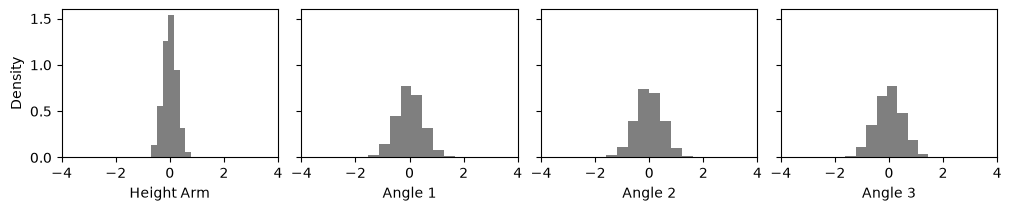

In [12]:
plot_params_kinematic(params2=training_data['parameters'])

Now let's train our neural estimator for 200 epochs! This will take around 2 minutes.

In [13]:
# The adapter tells the workflow what the input to our neural network is and how the target is called
adapter = (
    bf.adapters.Adapter()
    .to_array() # we could do more complex transformations here
    .convert_dtype("float64", "float32")
    .rename("parameters", "inference_variables")
    .rename("observables", "inference_conditions")
)

# Create a simple workflow
workflow_dm = bf.BasicWorkflow(
    adapter=adapter,
    simulator=simulator,
    inference_network=bf.networks.DiffusionModel(),
    standardize='inference_conditions'
)

# Train for 200 epochs (passes through the simulated data)
history = workflow_dm.fit_offline(
    training_data,
    epochs=200,
    batch_size=128,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 2.1684
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4562
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5550
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2612
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2017
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1181
Epoch 7/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1995
Epoch 8/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0732
Epoch 9/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0984
Epoch 10/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0115
Epoch 11/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0016
Epoch 12/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0166
Epoch 13/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8990
Epoch 14/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0423
Epoch 15/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9706
Ep

INFO:bayesflow:Training completed in 1.19 minutes.


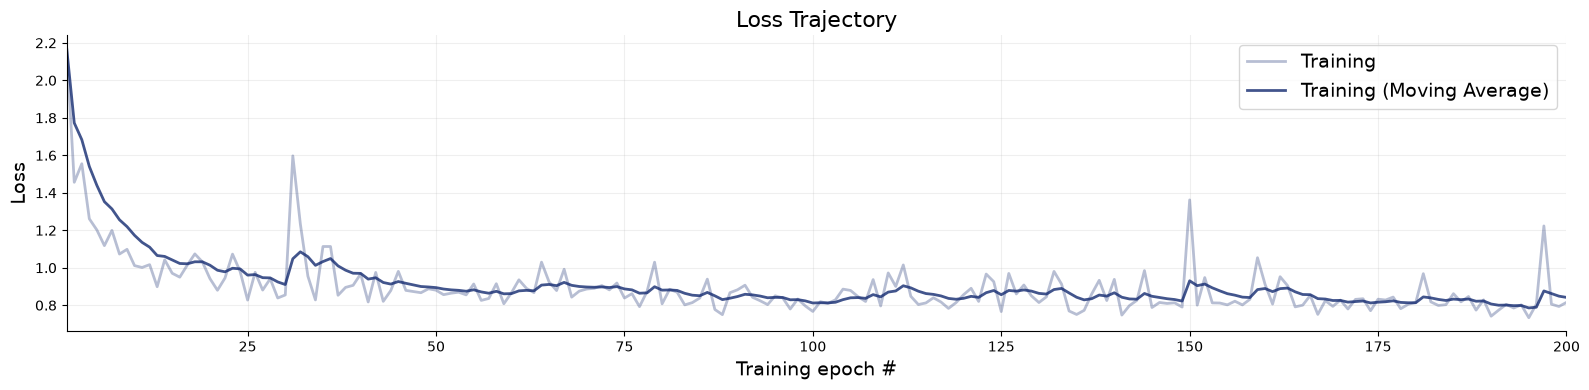

In [14]:
loss_plot = bf.diagnostics.plots.loss(
        history,
    )

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 6.85 seconds.


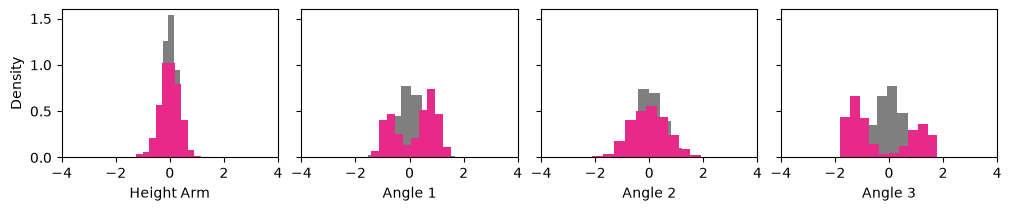

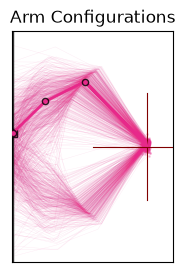

In [15]:
# Test amortized inference on new data
obs = {"observables": np.array([[0, 1.5]])}


# Sampling with the trained diffusion model
posterior_samples_single = workflow_dm.sample(
    conditions=obs,
    num_samples=1000
)

# Plot posterior samples for the parameters
plot_params_kinematic(
    posterior_samples_single['parameters'][0],
    training_data['parameters']
)

# Simulate with the posterior samples and plot them
plot_arm_posterior(posterior_samples_single, obs)

So something seems to have been learned. We get a nice bimodal posterior!

But are we sure that this is the correct posterior?
Let's do amortized inference on 100 datasets!

In [16]:
test_data = simulator.sample(100)

posterior_samples_test_data = workflow_dm.sample(
    conditions=test_data,
    num_samples=100,
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 8.19 seconds.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.67 seconds.


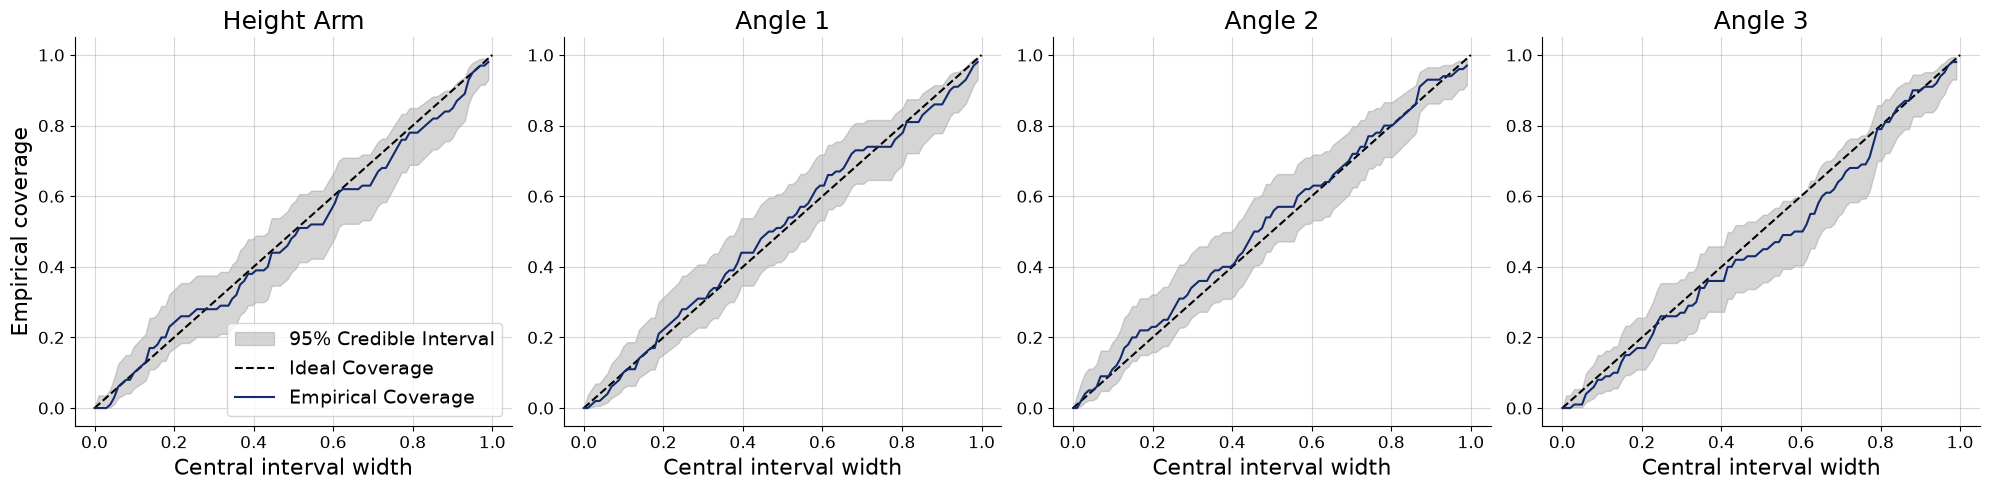

In [17]:
test_data = simulator.sample(100)

posterior_samples_test_data = workflow_dm.sample(
    conditions=test_data,
    num_samples=100,
)

fig = bf.diagnostics.plots.coverage(
    estimates=posterior_samples_test_data,
    targets=test_data,
    variable_names=variable_names_nice
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

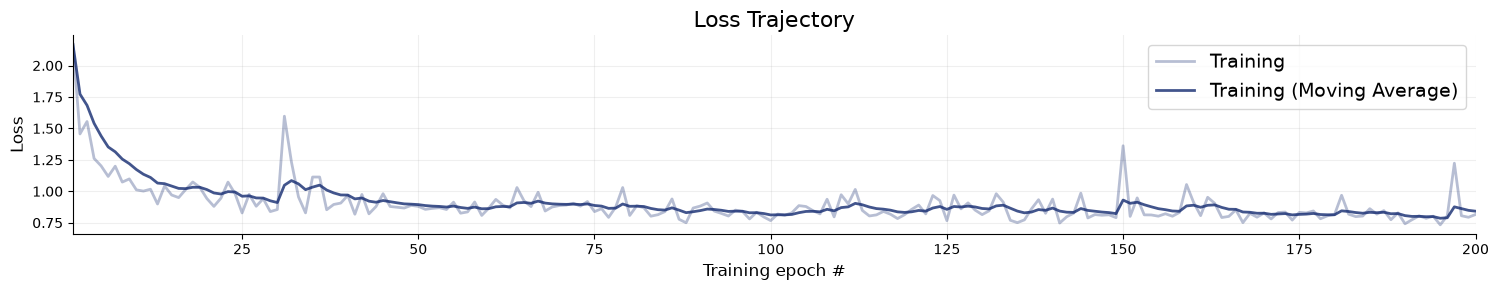

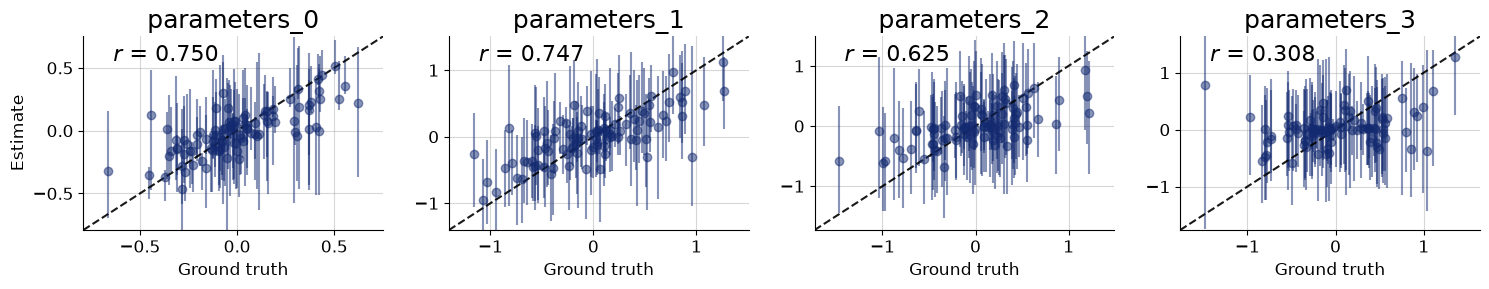

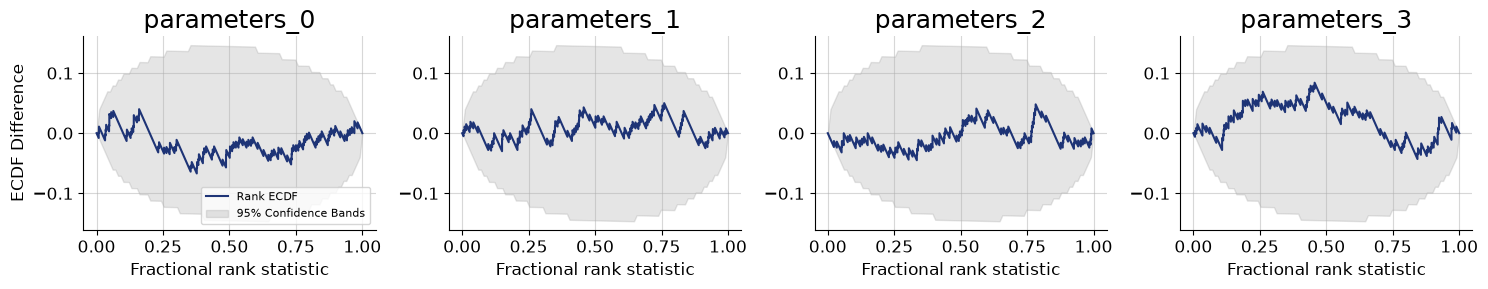

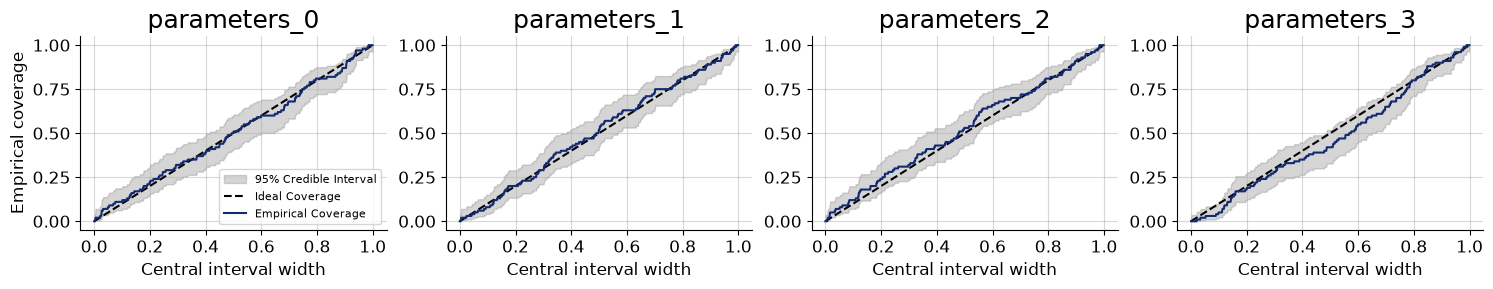

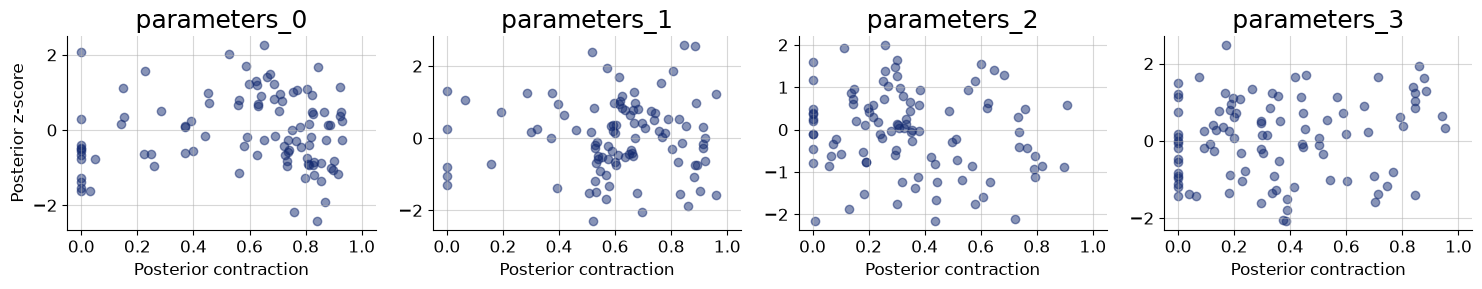

In [18]:
figures = workflow_dm.plot_default_diagnostics(
    test_data=test_data,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 8, "label_fontsize": 12},
    coverage_kwargs={"figsize": (15, 3), "legend_fontsize": 8, "label_fontsize": 12},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 12}
)

### Amortized Bayesian Inference

SBI is typically used in an **amortized** way, meaning we train a neural inference model once
and then reuse it for many observations.

#### Why amortization matters

Traditional Bayesian methods (e.g., MCMC) solve one inference problem at a time:
- new observation $\mathbf{x}_{\mathrm{obs}}$  → rerun MCMC
- computational cost grows linearly with the number of datasets.

With amortized inference we instead learn a global conditional model:
$q_\phi(\boldsymbol\theta\mid\mathbf{x}) \approx p(\boldsymbol\theta\mid\mathbf{x})$.


After training, posterior sampling for a new observation is fast and convenient:
We can **solve many inference problems** with only one neural network!

#### A note on the “amortization gap”

The network must generalize to new $\mathbf{x}$ values across the full simulated data space.
If simulations do not cover the region of interest, the approximation may degrade.
In practice this is addressed by better priors, more simulations, or robust inference methods.

## 2. What are Diffusion Models?

Diffusion models are generative models that create samples by *iteratively denoising* random noise.

In [19]:
drive_path

'/content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/'

The image file exists at: /content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/diffusion_model_review.jpeg


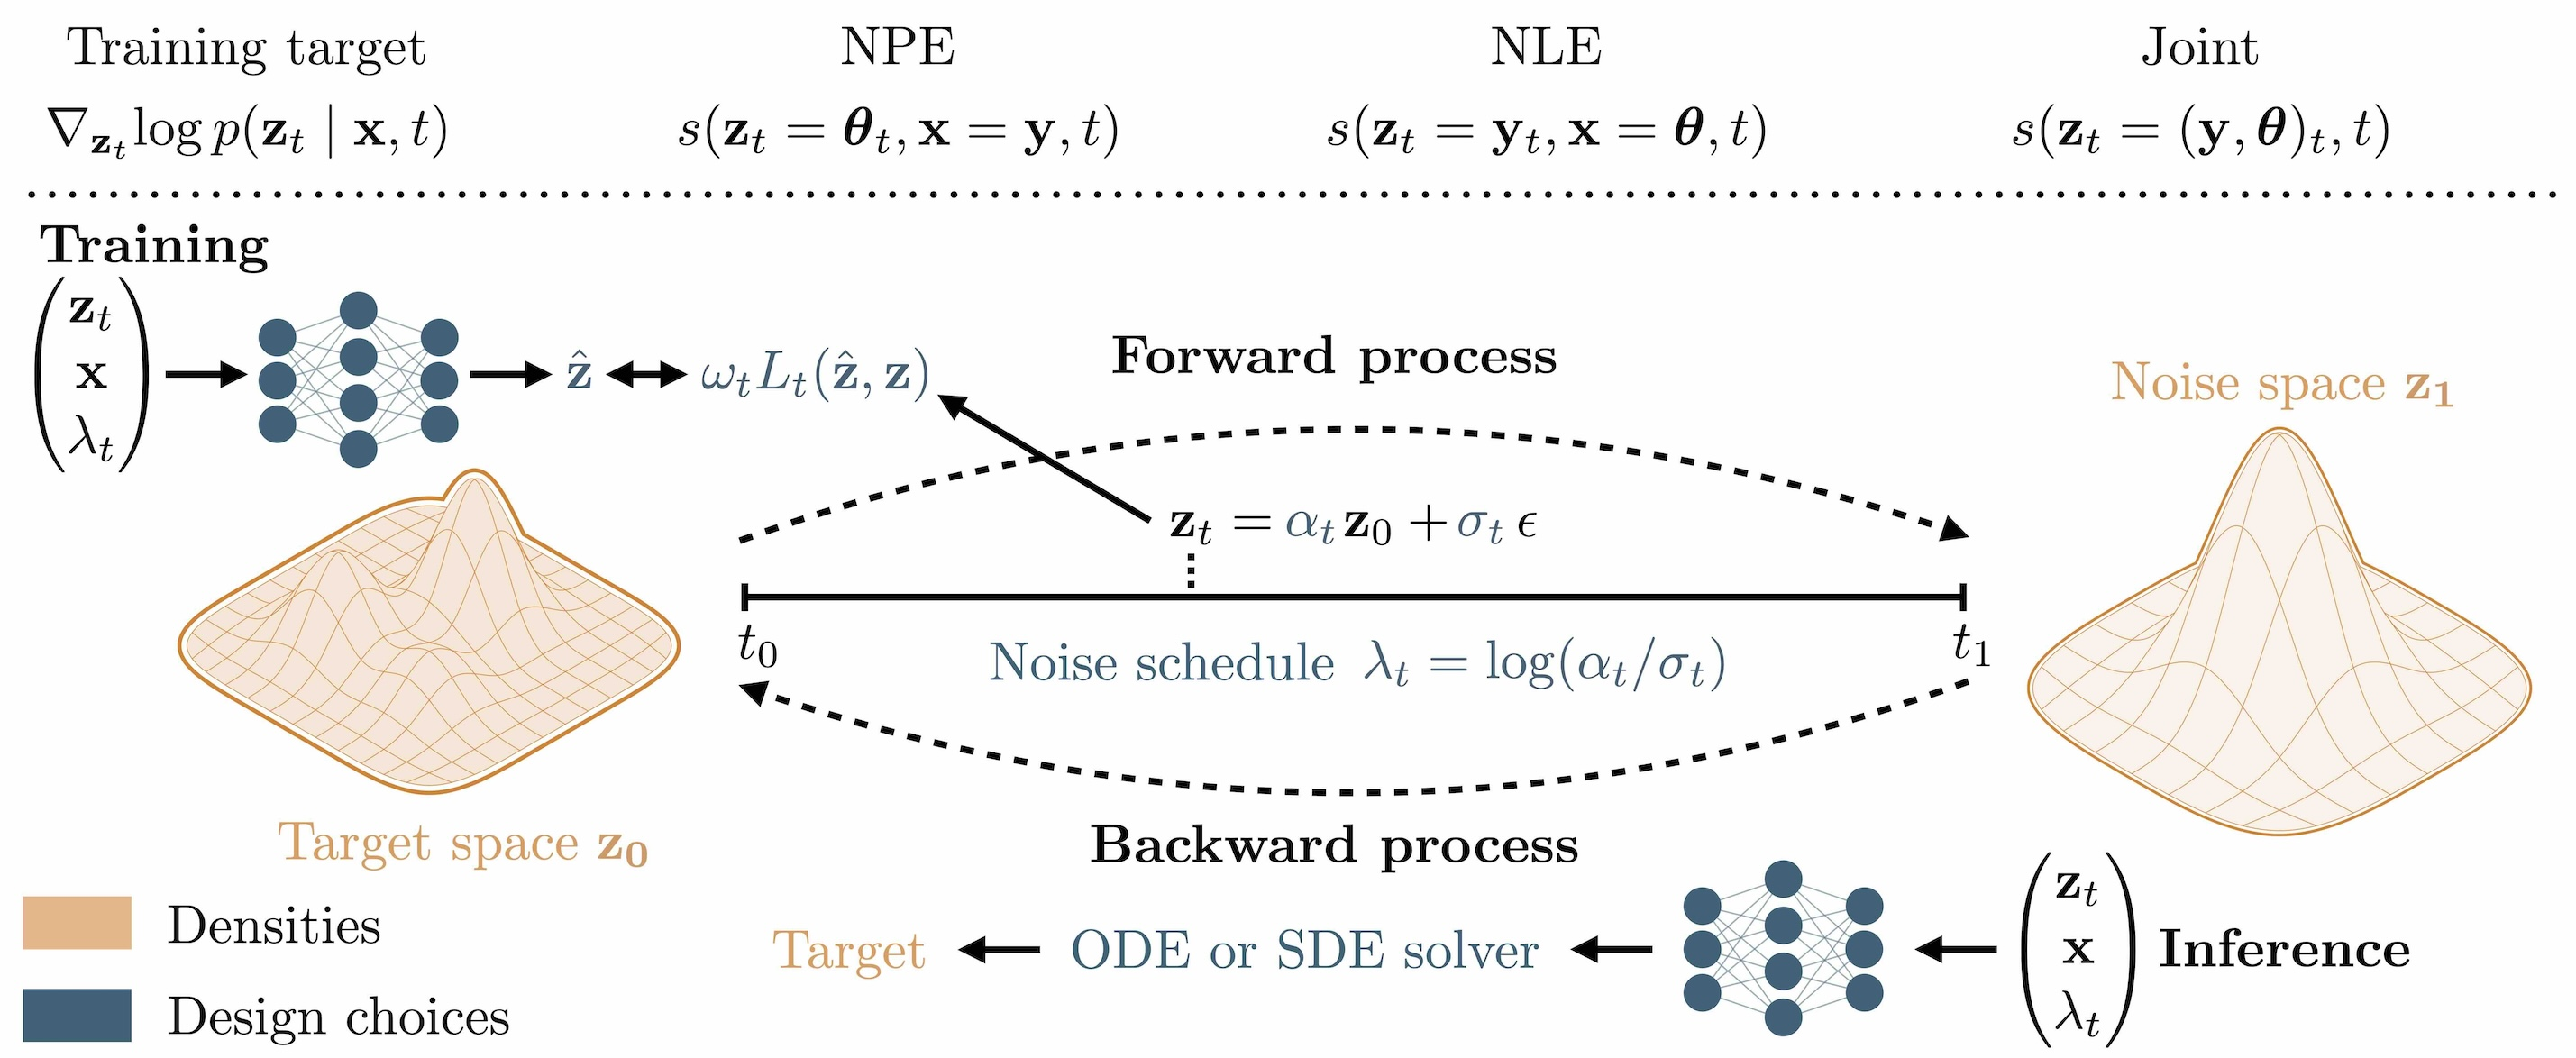

In [20]:
import os
from IPython.display import Image

image_path = os.path.join(drive_path,'diffusion_model_review.jpeg')

if os.path.exists(image_path):
    print(f"The image file exists at: {image_path}")
    display(Image(filename=image_path))
else:
    print(f"Error: The image file does not exist at: {image_path}")


### Forward process (Training)

We start with a clean sample $\boldsymbol\theta_0$ (here: a parameter vector) and gradually add noise:

$\boldsymbol\theta_t = \alpha_t\,\boldsymbol\theta_0 + \sigma_t\,\boldsymbol\epsilon, \quad \boldsymbol\epsilon \sim \mathcal{N}(0, I)$,

where $t \in [0,1]$ is a continuous diffusion time.
At $t \approx 1$, the distribution becomes close to pure noise.
Different choices of the *noise schedule* $\alpha_t$ and $\sigma_t$ determine how fast noise is added over time and have an impact on the performance later ([Arruda et al. (2025)](https://arxiv.org/abs/2512.20685)).

So what does the network actually learn?
It gets a noisy parameter $\boldsymbol\theta_t$ and the corresponding simulation $\mathbf{x}$ and predicts the score $\nabla_{\boldsymbol\theta_t}\!\log p(\boldsymbol\theta_t\mid\mathbf{x})$.

What is this score? It is the direction in which we need to move $\boldsymbol\theta_t$ to increase its probability under the posterior.
And it can be analytically computed from the noise schedule!

The image file exists at: /content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/score_visual.jpg


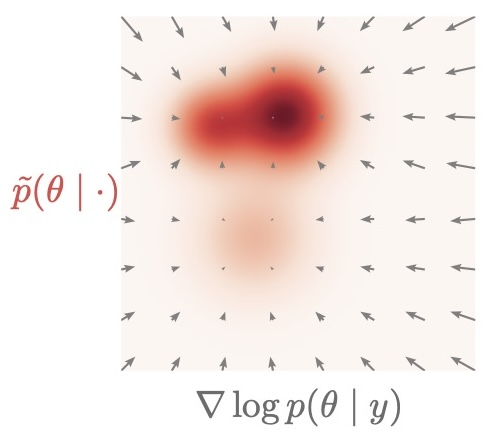

In [21]:
import os
from IPython.display import Image

image_path = os.path.join(drive_path, 'score_visual.jpg')

if os.path.exists(image_path):
    print(f"The image file exists at: {image_path}")
    display(Image(filename=image_path))
else:
    print(f"Error: The image file does not exist at: {image_path}")


### Reverse process (Inference)

The diffusion model learns how to move from noisy samples back to clean samples.
In practice, sampling is performed by solving a learned reverse-time stochastic differential equation (SDE) or an equivalent deterministic ODE.

And how? The reverse SDE/ODE is purely defined in terms of the noise schedule and the learned score!

In [22]:
logging.getLogger("bayesflow").setLevel(logging.ERROR)

import ipywidgets as widgets
from IPython.display import display

t_slider_backward = widgets.FloatSlider(
    value=1.0,
    min=0,
    max=1.0,
    step=0.05,
    description='Diffusion t:',
    continuous_update=True,
)


def update_plot(t):
    estimated_parameters_t = workflow_dm.sample(
        conditions=obs,
        num_samples=100,
        stop_time=t
    )

    plot_params_kinematic(
        estimated_parameters_t['parameters'][0]
    )

    print(f'Denoised Posterior at t={t}')

interact_output = widgets.interactive(update_plot, t=t_slider_backward)
display(interact_output)


interactive(children=(FloatSlider(value=1.0, description='Diffusion t:', max=1.0, step=0.05), Output()), _dom_…

### Short Summary

- Diffusion model learns a score function: $\nabla_{\boldsymbol\theta} \log p(\boldsymbol\theta\mid\mathbf{x})$, the "direction" it which we need to solve the reverse SDE
- Sample by starting from noise and iteratively denoising

This provides a highly expressive posterior approximation, especially useful for:
- multimodal posteriors,
- high-dimensional parameters,
- post-hoc modifications during inference.

## More generative models

The image file exists at: /content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/fm_cm_visual.jpg


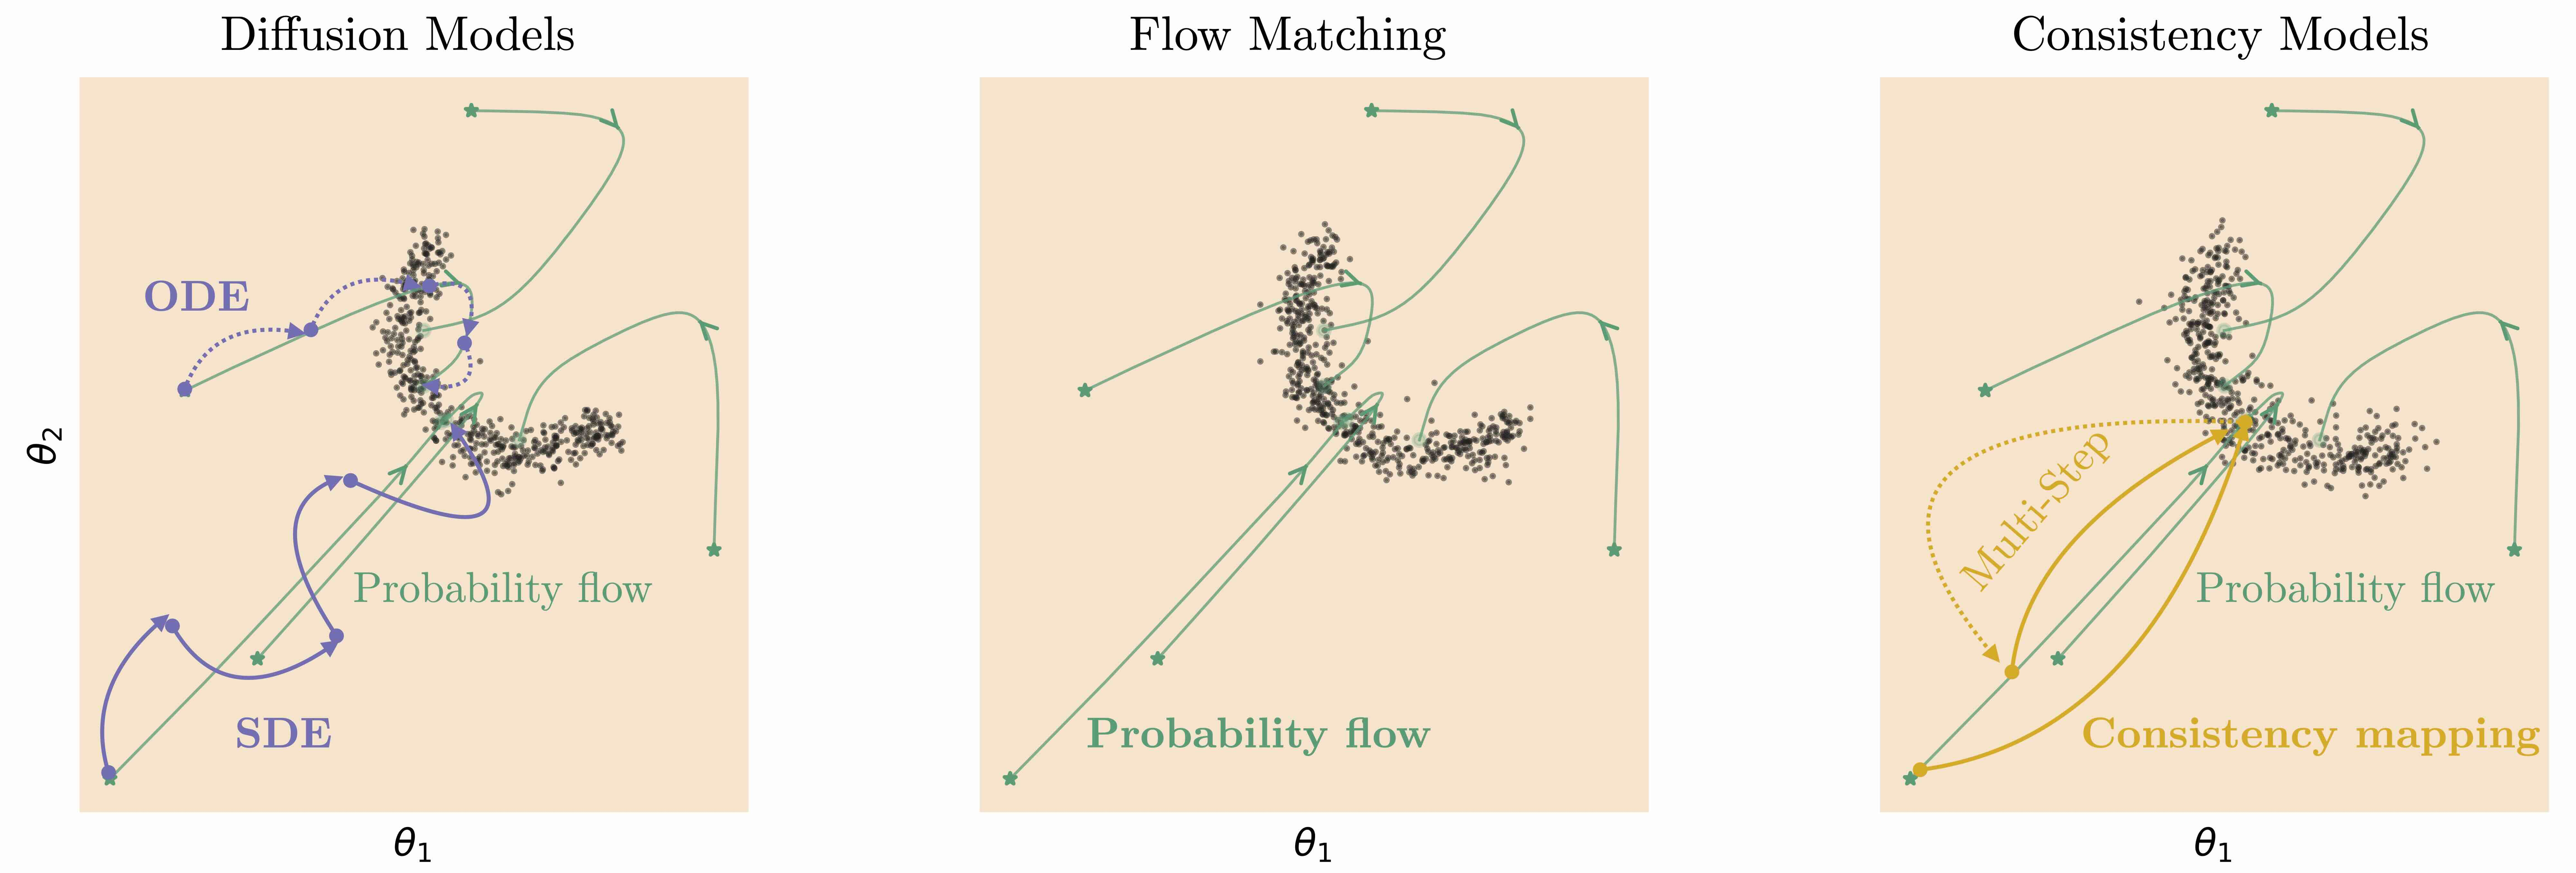

In [23]:
import os
from IPython.display import Image

image_path = os.path.join(drive_path,'fm_cm_visual.jpg')

if os.path.exists(image_path):
    print(f"The image file exists at: {image_path}")
    display(Image(filename=image_path))
else:
    print(f"Error: The image file does not exist at: {image_path}")


Related generative models can be considered a different *parameterization* of a **diffusion model**:
- **Flow matching**: we directly predict the vector field of the deterministic reverse path
- **Consistency models**: designed for very fast sampling by learning to jump directly to clean samples

All of these models are available in BayesFlow. So let's train some more models and compare their performance on our inverse kinematics problem!

```python

workflows = {}

workflows['diffusion_model'] = workflow_dm

workflow_fm = bf.BasicWorkflow(
    adapter=adapter,
    simulator=simulator,
    inference_network=bf.networks.FlowMatching(),
    standardize='inference_conditions'
)
workflows['flow_matching_model'] = workflow_fm

workflow_cm = bf.BasicWorkflow(
    adapter=adapter,
    simulator=simulator,
    inference_network=bf.networks.StableConsistencyModel(),
    standardize='inference_conditions'
)
workflows['consistency_model'] = workflow_cm

for _name in workflows.keys():

    # Diffusion workflow is already trained, so we skip it here
    if _name != 'diffusion_model':
        workflows[_name].fit_offline(
            training_data,
            epochs=200,
            batch_size=128,
            verbose=0
        )
```

There are lots of choices to make when designing a diffusion model, e.g.:
- Which noise schedule?
- Diffusion model vs. other generative models?

We explained and benchmarked them extensively in [Arruda et al. (2025)](https://arxiv.org/abs/2512.20685):

The image file exists at: /content/drive/MyDrive/Colab Notebooks/BayesflowTutorial/misc/diffusion/c2st_benchmark_boxplot_best.jpeg


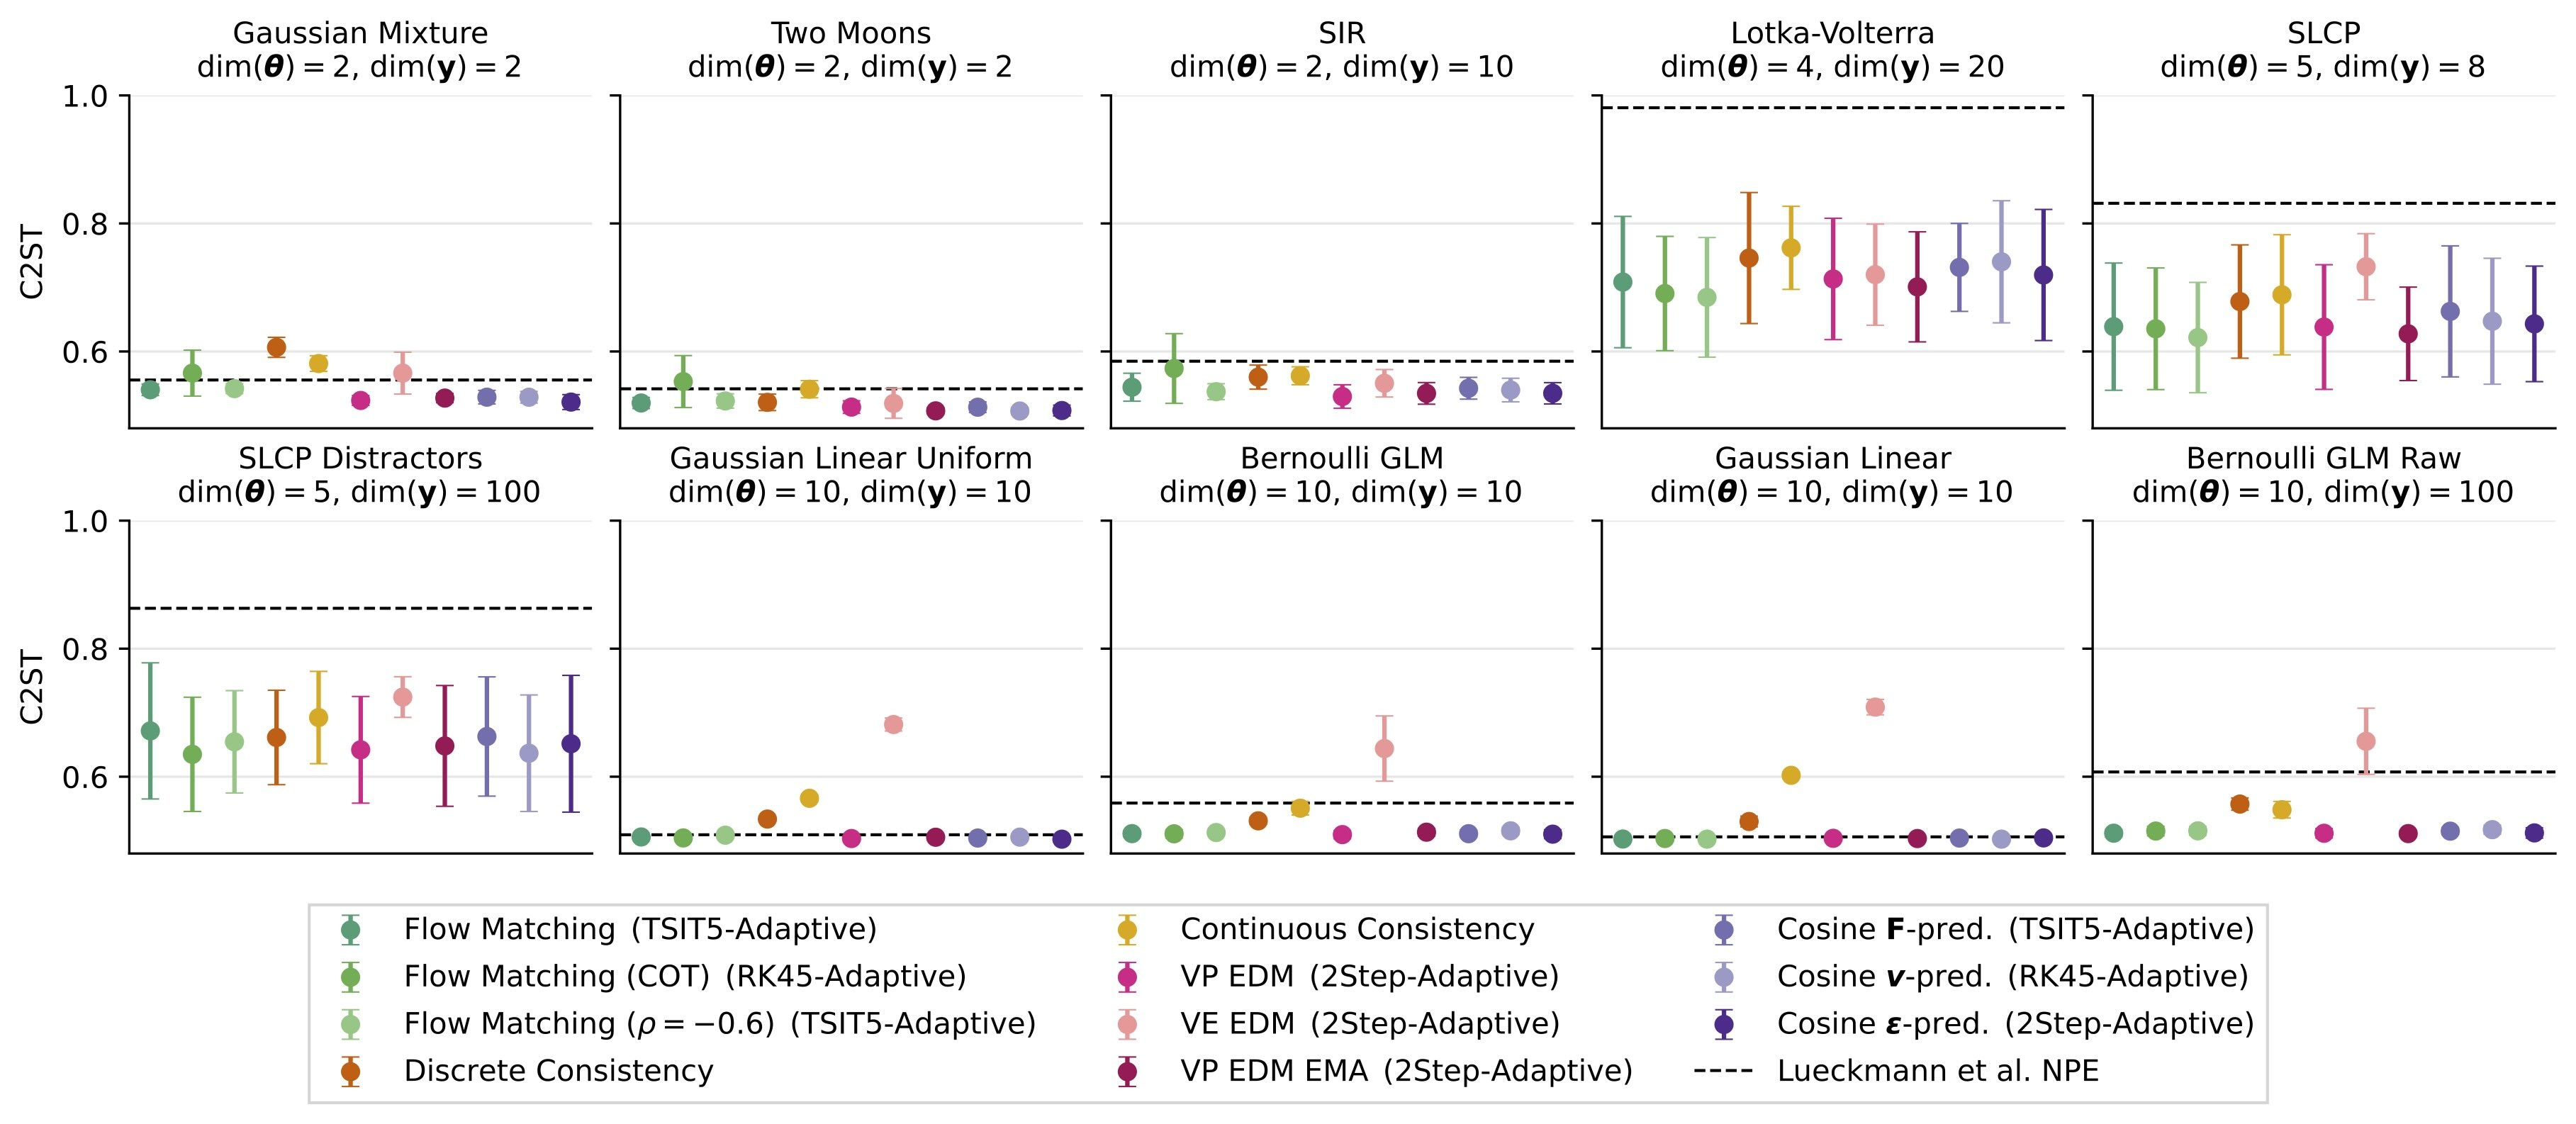

In [24]:
import os
from IPython.display import Image

image_path = os.path.join(drive_path, 'c2st_benchmark_boxplot_best.jpeg')

if os.path.exists(image_path):
    print(f"The image file exists at: {image_path}")
    display(Image(filename=image_path))
else:
    print(f"Error: The image file does not exist at: {image_path}")


## 3. Why are diffusion models so special for SBI?

Diffusion-based SBI provides two particularly useful properties.
We already have seen that they can tackle difficult and high-dimensional posteriors.

The real game changer is: score-based structure enables “post-hoc control”

Diffusion models learn a conditional vector field (a *score/velocity*-like object) that drives denoising.
This makes it possible to modify inference after training, for example:
- introducing additional constraints at sampling time,
- composing information from different sources.

This idea forms the basis of *compositional inference*, which is an active research direction for building scalable [hierarchical SBI methods](https://arxiv.org/abs/2505.14429).

![](misc/diffusion/adaptive_inference.jpg)

### Adaptation During Inference Time

The inverse-kinematics posterior is typically multimodal: multiple arm configurations can match the same
end-position. Here, we steer sampling *during reverse diffusion* by adding the gradient of a
differentiable "preference" term to the learned reverse dynamics.

We use the first angle of the "elbow" as a simple selector:
- **Elbow-up**
- **Elbow-down**

In [25]:
def elbow_up_down_constraint(workflow, target="elbow-up"):
    """
    Constraint for guided diffusion: pick "elbow-up" or "elbow-down".

    The rule is always:
        constraint is satisfied  <=>  c(zt) <= 0

    - If target="elbow-up":
          c(zt) =  -sin(a1)    -> wants sin(a1) >= 0
    - If target="elbow-down":
          c(zt) = sin(a1)    -> wants sin(a1) <= 0
    """
    sign = -1.0 if target == "elbow-up" else 1.0

    def c_elbow(z):
        if 'inference_variables' in workflow.approximator.standardize_layers:
            z = workflow.approximator.standardize_layers["inference_variables"](z, forward=False)
        a1 = z[..., 1]
        return sign * keras.ops.sin(a1)

    return c_elbow

In [26]:


mode = widgets.RadioButtons(
    options=["elbow-up", "elbow-down"],
    value='elbow-up',
    description='Steering target:',
    continuous_update=True,
)

strength = widgets.FloatSlider(
    value=0.0,
    min=0,
    max=1.0,
    step=0.01,
    description='Guidance strength λ:',
    continuous_update=True,
)

def update_guided_plot(mode_value, strength_value):
    # Draw samples with and without guidance for side-by-side comparison
    constraints = [elbow_up_down_constraint(
        workflow_dm, target=str(mode_value)
    )]

    theta_unguided = workflow_dm.sample(
         conditions=obs,
         num_samples=300,
    )
    theta_unguided = theta_unguided['parameters'][0]

    theta_guided = workflow_dm.sample(
         conditions=obs,
         num_samples=300,
         guidance_constraints=dict(
             constraints=constraints,
             guidance_strength=float(strength_value),
         )
    )
    theta_guided = theta_guided['parameters'][0]

    # Visualize effect on arm configurations
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw=dict(box_aspect=1.0), layout="constrained")

    model_left = InverseKinematicsModel(linecolors=["#E7298A"] * 3)   # unguided
    model_right = InverseKinematicsModel(linecolors=["#E7298A"] * 3)  # guided

    model_left.update_plot_ax(
        ax[0],
        theta_unguided,
        obs["observables"][0, ::-1],
        exemplar_color="#E7298A",
    )
    model_right.update_plot_ax(
        ax[1],
        theta_guided,
        obs["observables"][0, ::-1],
        exemplar_color="#E7298A",
    )

    ax[0].set_title("Posterior samples")
    ax[1].set_title(f"Guided posterior samples ({mode_value}, λ={strength_value})")
    plt.show()

# Assuming 'mode' and 'strength' widgets are already defined and displayed elsewhere
interact_output_guidance = widgets.interactive(update_guided_plot, mode_value=mode, strength_value=strength)
display(interact_output_guidance)


interactive(children=(RadioButtons(description='Steering target:', options=('elbow-up', 'elbow-down'), value='…

# The Bayesflow library is super cool!

It is really suggested to take a look at the example page! The main topic that you might be interested in (based on the discussion during the conference) are:

*  [How to compress the observation: Summary Networks](https://bayesflow.org/v2.0.10/_examples/SIR_Posterior_Estimation.html): an example of how to set up a summary network for highly dimensional observations (image, SED, time_series, ...). The basic idea is to change adapter and workflow to make them aware of what variables should be passed through the `summary_network`. We are going to date by using the `summary_variables` definition in the `adapter`:

  ```python
  adapter = (
    bf.adapters.Adapter()
    .to_array() # we could do more complex transformations here
    .convert_dtype("float64", "float32")
    .rename("parameters", "inference_variables")
    .rename("observables", "summary_variables") #<- will be passed to the summary network
  )

  workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network = bf.networks.ConvolutionalNetwork(), #<- in the case of images
    inference_network=bf.networks.DiffusionModel(),
    standardize='inference_conditions'
  )
  ```

*   [Multimodal data observations](https://bayesflow.org/v2.0.10/_examples/Multimodal_Data.html): Neural Posterior Estimation when your observation needs separate network (image + SED + time series/ light curves, ...)
*   [Neural Likelihood estimation](https://bayesflow.org/v2.0.10/_examples/Spatial_Data_and_Parameters.html): How to get a Stocastic Emulator using diffusion model (image generation task, but you would need 'just' to adjust the backbone network to better include your inductive bayas)

*  [Model mispecification checks](https://arxiv.org/pdf/2112.08866): Similar to the Confidence-Score described by Alessandro, it is useful to ask the question: "Is my model mispecified ?"

* [Amortized Model comparison](https://bayesflow.org/v2.0.10/_examples/One_Sample_TTest.html): given the following physical models (simulators, general modelling assumption), which one is the most consistent with my observation?

